### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_27746/3549569984.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


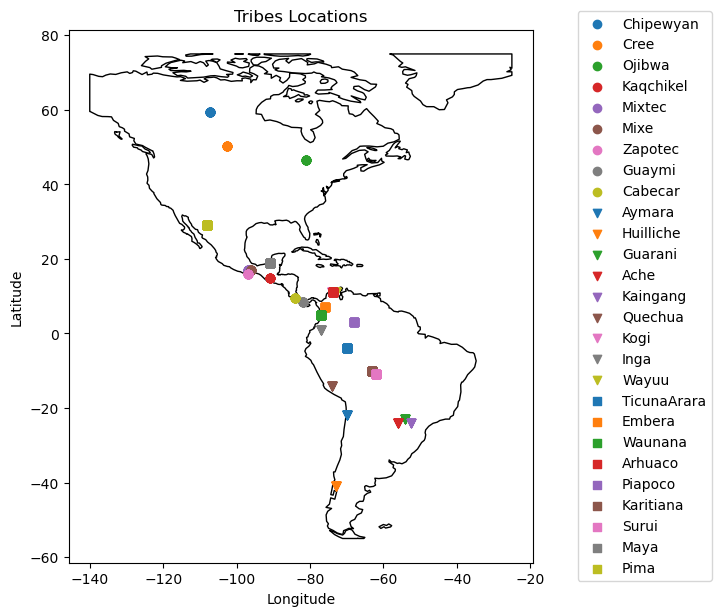

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6] # every lines, col 6
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
# loads land data (coordinates) of world map (set of polygons)
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

# creates plot
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

# crops desired area of subplot (not complete world map)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# for each tribe, plots a point (scatter)
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], # marker according to index
               color=colors_list[i%9], label=tribe)

# defines legends and shows
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [2]:
import numpy as np

# We remove all the columns except those for genetic markers
X = df.iloc[:,8:]

# Select the longitude column
y = df[['long']]

# Solving X.T * X * beta = X.T * y
beta = np.linalg.solve(X.T @ X, X.T @ y)

print(beta)

LinAlgError: Singular matrix

rank(X) - maximal number of linearly independent columns of A

We have $\text{rank}(X) < p$ so the columns of $X$ are linearly dependent, then $(X^\top X)$ is singular so it cannot be inverted.

Therefore np.linalg.solve fails with error `"Singular matrix"`.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [3]:
# We just change solve with lstsq (least-squares solution)
beta = np.linalg.lstsq(X.T @ X, X.T @ y)
beta

(array([[-0.04005781],
        [-0.01940898],
        [ 0.01111306],
        ...,
        [-0.21729626],
        [-0.10210421],
        [ 0.01813644]], shape=(5709, 1)),
 array([], dtype=float64),
 np.int32(494),
 array([1.22595906e+05, 3.75526477e+03, 3.18897815e+03, ...,
        1.06491520e-11, 2.42038467e-12, 2.52030528e-13], shape=(5709,)))

When using [`lstsq`](https://numpy.org/devdocs/reference/generated/numpy.linalg.lstsq.html) in place of `solve`, we get a solution at the end without any error.

It works because `lstsq` uses numerical methods based on $\textbf{SVD (singular value decomposition)}$ and doesn't require the matrix to be invertible.

> If a is square and of full rank, then x (but for round-off error) is the “exact” solution of the equation. Else, x minimizes the Euclidean 2-norm 
. If there are multiple minimizing solutions, the one with the smallest 2-norm 
 is returned.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [4]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
print(f'shape: {X.shape}')
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

shape: (494, 5709)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
lr.coef_

array([-0.03940988, -0.0245272 ,  0.01089763, ...,  0.04804479,
       -0.08985062,  0.01903025], shape=(5709,))

`sklearn` **recenters** predictors so that the intercept corresponds to the prediction when predictors are at their mean values, making it more interpretable and numerically stable.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

$\hookrightarrow$ Principal Component Analysis (PCA) is a method used to reduce the dimensionality of a dataset while keeping as much variability in the data as possible.

$\hookrightarrow$ From a geometric point of view, PCA finds new orthogonal directions (principal components) that maximize the variance of the data. These directions correspond to the eigenvectors of the covariance matrix, while the associated eigenvalues measure how much variance is explained by each component.

$\hookrightarrow$ From a statistical perspective, PCA transforms the original possibly correlated variables into a new set of uncorrelated variables that are linear combinations of the original variables. By keeping only the first few principal components (those with the largest eigenvalues), we can reduce the dimensionality of the data while preserving most of its variability.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

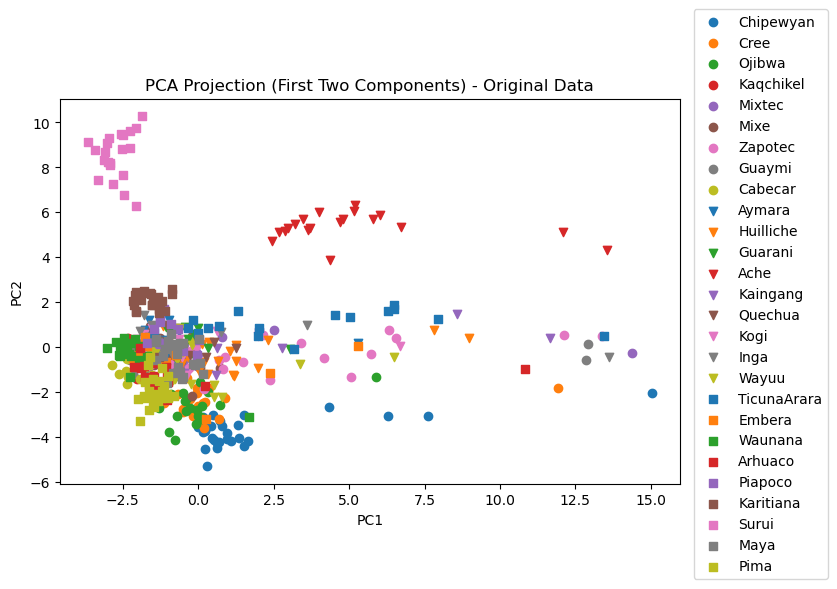

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

def pca_then_plot(X, title="PCA Projection (First Two Components)"):

    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8,5))

    for i, tribe in enumerate(df['Pop'].unique()):
        members = tribes == tribe
        plt.scatter(X_pca[members,0], X_pca[members,1],
                    marker=marker_list[i//9],
                    color=colors_list[i%9],
                    label=tribe)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.25,1.25))
    plt.show()
    
pca_then_plot(X, title="PCA Projection (First Two Components) - Original Data")


**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

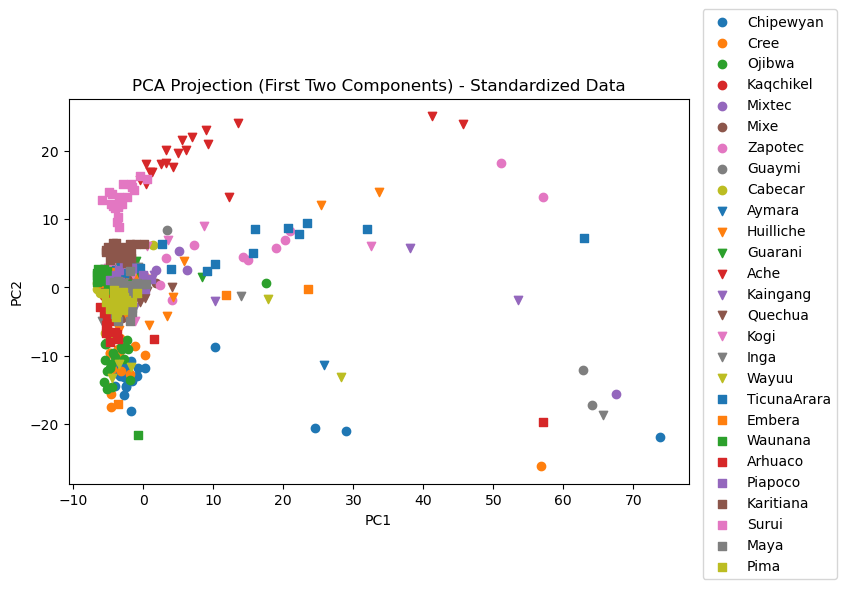

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

pca_then_plot(X_std, title="PCA Projection (First Two Components) - Standardized Data")

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

$\hookrightarrow$ Standardizing the data changes the PCA projection because PCA is sensitive to the scale of the variables.

$\hookrightarrow$ If variables have different variances, those with larger variance dominate the principal components. By standardizing the dataset, all variables have mean 0 and variance 1, so each genetic marker contributes equally to the PCA.

$\hookrightarrow$ Therefore, standardization is generally necessary when variables are measured on different scales or have very different variances. In this dataset, standardization allows PCA to capture the true structure of the genetic data rather than being dominated by markers with larger variance.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Total number of components: 494
For the first 2 PCs, the variance is: 3.3929133203688004 %
Components for 90% cummulative_variance: 376
Components for 95% cummulative_variance: 425


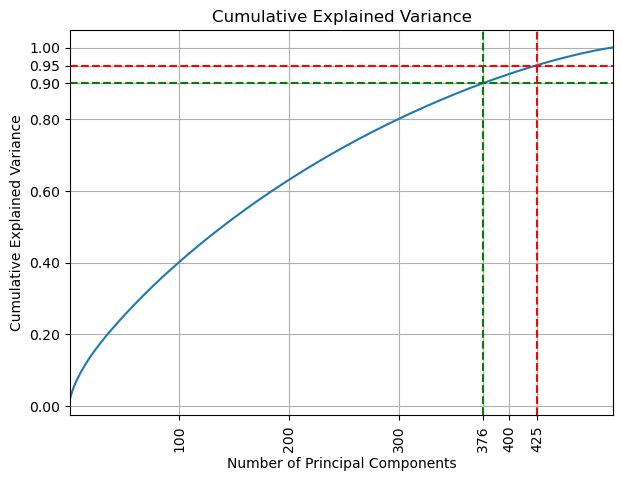

In [8]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_std)

explained_var_ratios = pca.explained_variance_ratio_
cummulative_explained_var_ratios = np.cumsum(explained_var_ratios)

# find number of components for 90% and 95%
q90 = np.argmax(cummulative_explained_var_ratios >= 0.90) + 1
q95 = np.argmax(cummulative_explained_var_ratios >= 0.95) + 1

print("Total number of components:", len(explained_var_ratios))
print("For the first 2 PCs, the variance is:",
      np.sum(explained_var_ratios[:2])*100, "%")
print("Components for 90% cummulative_variance:", q90)
print("Components for 95% cummulative_variance:", q95)

x = np.arange(1, len(cummulative_explained_var_ratios) + 1)

plt.figure(figsize=(7,5))
plt.plot(x, cummulative_explained_var_ratios)

plt.axhline(0.90, linestyle='--', color='green')
plt.axhline(0.95, linestyle='--', color='red')

plt.axvline(q90, linestyle='--', color='green')
plt.axvline(q95, linestyle='--', color='red')

# add ticks including q90 and q95
xticks = list(plt.xticks()[0])
xticks.extend([q90, q95])
plt.xticks(sorted(set(xticks)), rotation=90)

plt.yticks(np.arange(0, 1.1, 0.2).tolist() + [0.90, 0.95])

plt.xlim(1, len(x))

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid()
plt.show()

$\hookrightarrow$ The first two principal components capture approximately **3.4%** of the total variance.

$\hookrightarrow$ From the cumulative variance plot, we observe that approximately **400 principal components out of 492** are required to explain about **90–95%** of the total variance, and approximately **300 principal components** are needed to explain about **80%** of the total variance.

$\hookrightarrow$ This indicates that the variance in the dataset is distributed across many dimensions. Therefore, a relatively large number of principal components must be retained to preserve most of the variability in the data.

$\hookrightarrow$ Keeping around **400 principal components** provides a lower-dimensional representation of the genetic markers while preserving most of the information contained in the original dataset.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

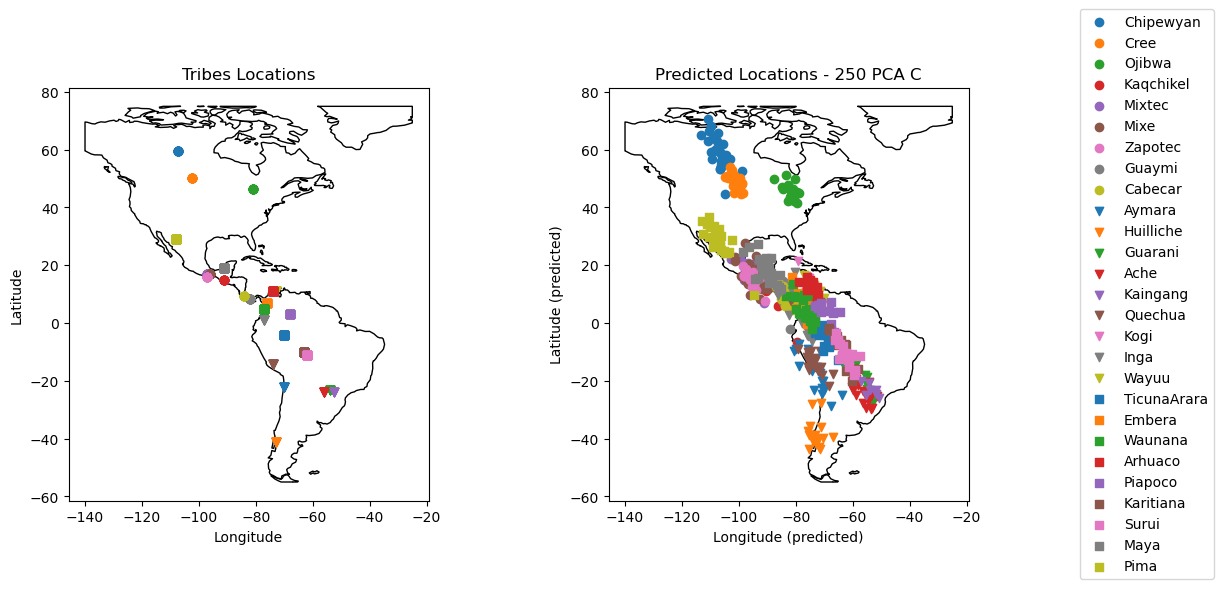

In [9]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# PCA with 250 components
pca = PCA(n_components=250)
X_pca = pca.fit_transform(X_std)

# targets
y_lat = df["lat"]
y_long = df["long"]

# regressions
reg_lat = LinearRegression()
reg_long = LinearRegression()

reg_lat.fit(X_pca, y_lat)
reg_long.fit(X_pca, y_long)

# predictions on y
lat_pred = reg_lat.predict(X_pca)
long_pred = reg_long.predict(X_pca)

# creates plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.0, 8.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

# crops desired area of subplot (not complete world map)
world.clip([-140, -55, -25, 75]).plot(ax=ax1, color='white', edgecolor='black')
world.clip([-140, -55, -25, 75]).plot(ax=ax2, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# Original position
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax1.scatter(
        members_tribe['long'], 
        members_tribe['lat'], 
        marker=marker_list[i//9], # marker according to index
        color=colors_list[i%9], 
        label=tribe
    )

# predicted position
for i, tribe in enumerate(df['Pop'].unique()):
    members = gdf['Pop'] == tribe
    ax2.scatter(
        long_pred[members],
        lat_pred[members],
        marker=marker_list[i//9],
        color=colors_list[i%9],
        label=tribe
    )

ax2.set_xlabel("Longitude (predicted)")
ax2.set_ylabel("Latitude (predicted)")
ax2.set_title("Predicted Locations - 250 PCA C")

# defines legends and shows
ax1.set_title('Tribes Locations')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.legend(loc='center right', bbox_to_anchor=(1.7, 0.5))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

$\hookrightarrow$ Using the first 250 PCA components, we performed principal components regression to predict the latitude and longitude of individuals from their genetic marckers. The predicted spatial coordinates show clusters that roughly resemble the original geographic distribution of populations. Individuals from the same population remain grouped together, and the overall structure appears similar to the original map.

$\hookrightarrow$ However, this result is somewhat **optimistic**. The regression model was trained and evaluated on the **same dataset**, meaning that the model may overfit the data. Because of this, the model may appear to predict geographic origin more accurately than it would for individuals outside the database.

$\hookrightarrow$ Therefore, the map may **overestimate the ability** to determine the geographical origin of new individuals based solely on their genetic markers. A proper evaluation would require testing the model on individuals that were not used during training.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [10]:
from sklearn.metrics.pairwise import haversine_distances

def haversine_error(lat_p, long_p, lat, long):
    # Calculate the Haversine distances between predicted and actual coordinates
    actual_coords = np.radians(np.array([lat, long]).T)
    predicted_coords = np.radians(np.array([lat_p, long_p]).T)
    haversine_dist = haversine_distances(actual_coords, predicted_coords)
    # Convert distances from radians to kilometers (Earth's radius ~ 6371 km)
    R = 6371  # Earth radius in kilometers
    haversine_dist_km = np.diag(haversine_dist) * R
    return haversine_dist_km
    
print("Average Haversine distance (km):", np.mean(haversine_error(lat_pred, long_pred, df['lat'], df['long'])))

Average Haversine distance (km): 477.7367284933602


$\hookrightarrow$ The average Haversine distance between the real and predicted coordinates is approximately **500 km**. This metric quantifies the average error of the regression model in terms of geographic distance, providing a more interpretable measure of how well the model predicts the spatial coordinates based on genetic markers. On average, the predicted locations are about 500 km away from the actual locations, which indicates a moderate level of accuracy in predicting geographic origin based on genetic data.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

$\hookrightarrow$ Cross-validation is the principle of splitting the training set into $N$ different sets, using $N-1$ for training and $1$ for testing. We use this method to detect and prevent *overfitting* - simply learns each point, losing generalization. Normally, we iterate over our folds to evaluate the model, and return the median error found in the testing set. 

A dataset being not IID means that the data is not independently and identically distributed. In order to handle cases like this, we can use the following strategies:
- Time series split: for time-dependent data, we can split it by consecutive periods of time to preserve temporal dependencies. Ensuring that the training set contains data from earlier time periods and the testing set contains data from later time periods.
- Group k-fold: for data with group structures (multiple analyses from the same patient, for example), we can use group k-fold cross-validation, which ensures that all samples from the same group are either in the training set or in the testing set, preventing data leakage.
- Leave p groups out: leave-p-groups-out cross-validation uses p groups as a test set while the rest of the groups are used for training.



**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

$\hookrightarrow$ Given that in the dataset the tribes are grouped together, we can't use a simple KFold, because then we would have a biased testing subset.
Therefore, we should use the flag shuffle in the normal Kfold model, since the function ShuffleSplit() is only the iterator that generates the suffled groupes. In consequence, using KFold with shuffle=True shuffles the datafor each fold, ensuring that training and testing sets have a more distributed sample pool throughout the set.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import ShuffleSplit, cross_val_predict, KFold
from sklearn.pipeline import make_pipeline

scaler = StandardScaler()
pca = PCA(n_components=4)
rs = KFold(n_splits=10, shuffle=True, random_state=10)
lr = LinearRegression()
est = make_pipeline(scaler, pca, lr)

lat_pred = cross_val_predict(est, X, y_lat, cv=rs)
long_pred = cross_val_predict(est, X, y_long, cv=rs)

haversine_err = haversine_error(lat_pred, long_pred, y_lat, y_long)
print(f'haversine distance: {np.mean(haversine_err)}')

haversine distance: 2016.1372271162122


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [12]:
results = []
X = pd.DataFrame(df.iloc[:,8:])

for comps in range(2, 440, 10):
    rs = KFold(n_splits=10, shuffle=True, random_state=10)
    # creates objects
    lat_est = make_pipeline(
        StandardScaler(), 
        PCA(n_components=comps), 
        LinearRegression()
    )
    long_est = make_pipeline(
        StandardScaler(), 
        PCA(n_components=comps), 
        LinearRegression()
    )
    tr_err = []
    te_err = []
    
    for i, (train_idx, test_idx) in enumerate(rs.split(X)): 
        # splits dataset into trainning and testing (for lat and long)
        X_tr, y_lat_tr, y_long_tr = X.iloc[train_idx], y_lat.iloc[train_idx], y_long.iloc[train_idx]
        X_te, y_lat_te, y_long_te = X.iloc[test_idx], y_lat.iloc[test_idx], y_long.iloc[test_idx]
        
        # fits models
        lat_est.fit(X_tr, y_lat_tr)
        long_est.fit(X_tr, y_long_tr)

        # calculates predictions for current fold
        lat_pred_tr = lat_est.predict(X_tr)
        long_pred_tr = long_est.predict(X_tr)
        lat_pred_te = lat_est.predict(X_te)
        long_pred_te = long_est.predict(X_te)

        # appends mean haversine error for current fold (trainning and testing)
        h_err_tr = haversine_error(lat_pred_tr, long_pred_tr, y_lat_tr, y_long_tr)
        h_err_te = haversine_error(lat_pred_te, long_pred_te, y_lat_te, y_long_te)
        tr_err.append(np.mean(h_err_tr))
        te_err.append(np.mean(h_err_te))

    # appends mean error across all folds
    results.append({
        "components:": comps,
        "haversine_error_tr": np.mean(tr_err),
        "haversine_error_te": np.mean(te_err)
    })

results

[{'components:': 2,
  'haversine_error_tr': np.float64(2074.8616032650343),
  'haversine_error_te': np.float64(2108.795726755409)},
 {'components:': 12,
  'haversine_error_tr': np.float64(1423.2639697553802),
  'haversine_error_te': np.float64(1551.5317187237765)},
 {'components:': 22,
  'haversine_error_tr': np.float64(1320.1948522195541),
  'haversine_error_te': np.float64(1477.1575880302923)},
 {'components:': 32,
  'haversine_error_tr': np.float64(1095.2478167973254),
  'haversine_error_te': np.float64(1349.0801151250218)},
 {'components:': 42,
  'haversine_error_tr': np.float64(1011.670978048786),
  'haversine_error_te': np.float64(1306.5026428596523)},
 {'components:': 52,
  'haversine_error_tr': np.float64(1005.5242335539699),
  'haversine_error_te': np.float64(1316.3130469023574)},
 {'components:': 62,
  'haversine_error_tr': np.float64(938.953658603675),
  'haversine_error_te': np.float64(1278.7464979555873)},
 {'components:': 72,
  'haversine_error_tr': np.float64(895.3574530

> ⚠️ **LONG EXECUTION TIME**: Be very careful here!
>
> due to a long execution time (~30m on my machine), I saved the data in a csv file so we don't need to execute this every time

In [13]:
pd.DataFrame(results).to_csv('ex5-d.csv', index=False)

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

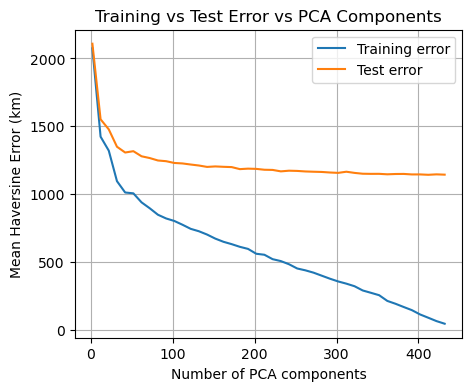

In [14]:
#results_df = results
results_df = pd.read_csv('ex5-d.csv')

plt.figure(figsize=(5,4))
plt.plot(results_df["components:"], results_df["haversine_error_tr"], label="Training error")
plt.plot(results_df["components:"], results_df["haversine_error_te"], label="Test error")

plt.xlabel("Number of PCA components")
plt.ylabel("Mean Haversine Error (km)")
plt.title("Training vs Test Error vs PCA Components")
plt.legend()
plt.grid(True)
plt.show()

$\hookrightarrow$ We can see that the model starts to overfit at about *100 components*, that is, the training error keeps getting small while the testing error remains stable or gets smaller much slower. That said, I would keep a model with around 100 components.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

$\hookrightarrow$ In this study, we used principal components regression to predict the geographical coordinates of individuals based on their genetic markers. Through exercise 4 and 5 we were able to see that there is a great difference in the predicted error when using the the same dataset for training and testing, and when using cross-validation. This evidences the importance of choosing an appropriate validation strategy, specialy considering how someone can be influenceed into thinking about the performance of a model with a lower error but that is overfitted to the training set. 

$\hookrightarrow$ The choice of which model to use is also highly dependant on the context and on the dataset. In our case, we have a dataset which contains the individuals of the same tribe grouped together, and in order to avoid not having trained the model from people from a specific tribe (if it for example was left out of the training set), we had to shuffle the data before training. If, however, we had a slightly different objective, for example judging if someone from a new tribe could suffer from a condition based on their genetic markers, then we would have the need to develop a model that traces the conditon to a specific gene, and that would be subjected to genetic markers that vary further from the ones used to training. This would be a case where we would need to use a different validation strategy, such as the leave-p-groups-out cross-validation, which would allow us to test the model on a new tribe that was not used during training, and that would render us able to generalize the model to new populations for this suposed purpose. This idea is brought up as a note in the scikit-learn documentation for cross validation, in which suffling in this hypothetical situation would actually contribute to an overfitting (which can be seen in the documentation's example below).

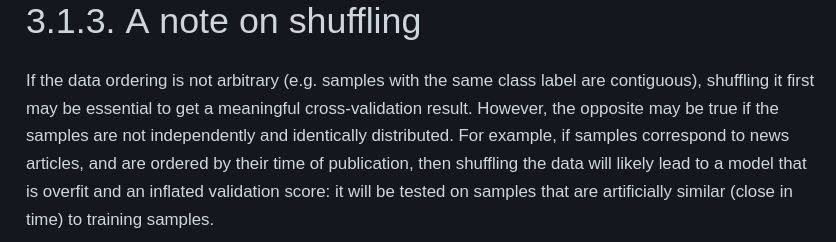

$\hookrightarrow$ Through the results, it's possible to see that the haversine error for the test set and training set falls at the same rate for the first components, and after that the testing error starts decreasing slower. At around 100 components, the training error keeps getting smaller while the testing error starts halting its decrease, which is a sign of overfitting. We can conclude that in this case, the best models take into consideration the first components, taht act as quality predictors, while the later components don't contribute to the model's analysis.

$\hookrightarrow$ In order to further improve the robustness of our evaluation, we also considered using a stratified KFold instead of a normal shuffled KFold, since it would ensure that each fold has at least one representative of each tribe, which would be a more robust way to evaluate the model. This is possible with changing the number of folds to 7, since the smallest class has only 7 samples. The results and comparison can be seen in the annex below, and it's possible to see that the results are really similar between the two models. 

$\hookrightarrow$ Other than that we could also consider using partial least squares, which is a method that finds the components that explain the covariance between the predictors, instead of just the component's variance as in PCA. This could potentially lead to better predictions in the case where the prediction is influenced by genes that are not in the directions of bigger variances. The use of PLS would render the model capable of finding the components that are more relevant for the prediction task, which could lead to having a lower error withg less components in comparison to PCA, which blindly selects components based on variance. 

## Annex: Stratified KFold results

In [15]:
from sklearn.model_selection import StratifiedKFold

rs = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)

# We pass the split generator directly to cv instead of just the object
split_generator = list(rs.split(X, tribes)) 

lat_pred = cross_val_predict(est, X, y_lat, cv=split_generator)
long_pred = cross_val_predict(est, X, y_long, cv=split_generator)

/home/carlos-engler/anaconda3/envs/isla2026/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


In [16]:
from sklearn.model_selection import StratifiedKFold

results = []
X = pd.DataFrame(df.iloc[:,8:])


tribes = df.iloc[:, 2]

rs = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)

for comps in range(2, 440, 10):


    # creates objects
    lat_est = make_pipeline(
        StandardScaler(), 
        PCA(n_components=comps), 
        LinearRegression()
    )
    long_est = make_pipeline(
        StandardScaler(), 
        PCA(n_components=comps), 
        LinearRegression()
    )
    tr_err = []
    te_err = []
    
    for i, (train_idx, test_idx) in enumerate(rs.split(X, tribes)): 
        # splits dataset into trainning and testing (for lat and long)
        X_tr, y_lat_tr, y_long_tr = X.iloc[train_idx], y_lat.iloc[train_idx], y_long.iloc[train_idx]
        X_te, y_lat_te, y_long_te = X.iloc[test_idx], y_lat.iloc[test_idx], y_long.iloc[test_idx]
        
        # fits models
        lat_est.fit(X_tr, y_lat_tr)
        long_est.fit(X_tr, y_long_tr)

        # calculates predictions for current fold
        lat_pred_tr = lat_est.predict(X_tr)
        long_pred_tr = long_est.predict(X_tr)
        lat_pred_te = lat_est.predict(X_te)
        long_pred_te = long_est.predict(X_te)

        # appends mean haversine error for current fold (trainning and testing)
        h_err_tr = haversine_error(lat_pred_tr, long_pred_tr, y_lat_tr, y_long_tr)
        h_err_te = haversine_error(lat_pred_te, long_pred_te, y_lat_te, y_long_te)
        tr_err.append(np.mean(h_err_tr))
        te_err.append(np.mean(h_err_te))

    # appends mean error across all folds
    results.append({
        "components:": comps,
        "haversine_error_tr": np.mean(tr_err),
        "haversine_error_te": np.mean(te_err)
    })

results

/home/carlos-engler/anaconda3/envs/isla2026/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/home/carlos-engler/anaconda3/envs/isla2026/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/home/carlos-engler/anaconda3/envs/isla2026/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/home/carlos-engler/anaconda3/envs/isla2026/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/home/carlos-engler/anaconda3/envs/isla2026/lib/python3.14/site-packages/sklearn/model_selection/_sp

[{'components:': 2,
  'haversine_error_tr': np.float64(2060.8911689828287),
  'haversine_error_te': np.float64(2079.266234529847)},
 {'components:': 12,
  'haversine_error_tr': np.float64(1426.9129424921193),
  'haversine_error_te': np.float64(1537.0648932138527)},
 {'components:': 22,
  'haversine_error_tr': np.float64(1307.7445890694553),
  'haversine_error_te': np.float64(1447.14974552434)},
 {'components:': 32,
  'haversine_error_tr': np.float64(1110.288909091949),
  'haversine_error_te': np.float64(1346.3569598914441)},
 {'components:': 42,
  'haversine_error_tr': np.float64(992.1329111297476),
  'haversine_error_te': np.float64(1287.8189198382383)},
 {'components:': 52,
  'haversine_error_tr': np.float64(991.2449363411422),
  'haversine_error_te': np.float64(1279.655299296777)},
 {'components:': 62,
  'haversine_error_tr': np.float64(943.2820233258983),
  'haversine_error_te': np.float64(1260.286740928737)},
 {'components:': 72,
  'haversine_error_tr': np.float64(893.124214028571

In [17]:
pd.DataFrame(results).to_csv('stratifiedKFold.csv', index=False)

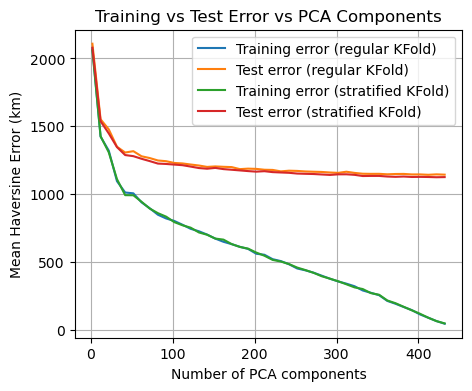

In [18]:
#results_df = results
results_df2 = pd.read_csv('stratifiedKFold.csv')

plt.figure(figsize=(5,4))
plt.plot(results_df["components:"], results_df["haversine_error_tr"], label="Training error (regular KFold)")
plt.plot(results_df["components:"], results_df["haversine_error_te"], label="Test error (regular KFold)")
plt.plot(results_df2["components:"], results_df2["haversine_error_tr"], label="Training error (stratified KFold)")
plt.plot(results_df2["components:"], results_df2["haversine_error_te"], label="Test error (stratified KFold)")

plt.xlabel("Number of PCA components")
plt.ylabel("Mean Haversine Error (km)")
plt.title("Training vs Test Error vs PCA Components")
plt.legend()
plt.grid(True)
plt.show()

The warning: 
```
UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
```

Means that the smallest class in the target variable has only 7 samples, which is less than the number of splits specified, and in consequence 3 folds won't have any samples from that class, which can lead to unreliable estimates of the model's performance for that class. This is something that we could compare to the results for the normal shuffled KFold, and its possible to see in the plot above that they are similar aswell.